Saving sunset.jpg to sunset.jpg


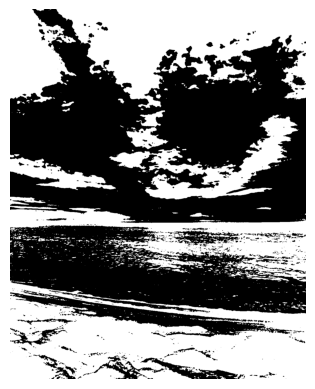

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


from google.colab import files
uploaded = files.upload()

# Read image
img = cv2.imread('sunset.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Otsu Thresholding
ret, thresh = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Morphological Closing
kernel = np.ones((9, 9), np.uint8)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

# Background using dilation
bg = cv2.dilate(closing, kernel, iterations=2)

# Find contours
contours, _ = cv2.findContours(
    closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

# Create empty image
result = np.zeros(gray.shape, dtype=np.uint8)

# Fill large contours
for contour in contours:
    if cv2.contourArea(contour) > 1000:
        cv2.fillPoly(result, [contour], 255)

# Opening operation
kernel_open = np.ones((6, 6), np.uint8)
opened_result = cv2.morphologyEx(
    result, cv2.MORPH_OPEN, kernel_open, iterations=2
)

# Erosion
kernel_erode = np.ones((9, 9), np.uint8)
final_result = cv2.erode(opened_result, kernel_erode, iterations=2)

# Show threshold image
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()




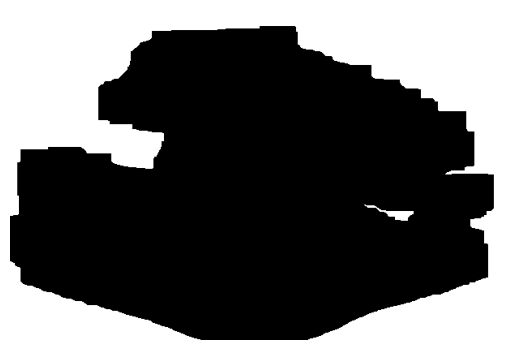

In [ ]:
# Show final result
plt.imshow(final_result, cmap='gray')
plt.axis('off')
plt.show()